In [1]:
import serial
import numpy as np
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

plt.style.use('dark_background')


In [2]:
with serial.Serial("COM31", 115200, rtscts=False) as ser:
    ser.write(b'hello\n')
    l = ser.readline().decode()
    print(l)


NEW Name Here Ready



In [166]:
cmd = '''
reset();

config(110, 10, 15, 1, 5, 4, 4, 5, 5);
set_arr(1, 0, 1, 10, 1, 0, 1);
set_arr(2, 1, 1, 10, 1, 1, 1);
set_arr(3, 0, 1, 10, 1, 0, 1);
run();


'''

cmd_str = "C:" + cmd + "?"
cmd_str

'C:\nreset();\n\nconfig(110, 10, 15, 1, 5, 4, 4, 5, 5);\nset_arr(1, 0, 1, 10, 1, 0, 1);\nset_arr(2, 1, 1, 10, 1, 1, 1);\nset_arr(3, 0, 1, 10, 1, 0, 1);\nrun();\n\n\n?'

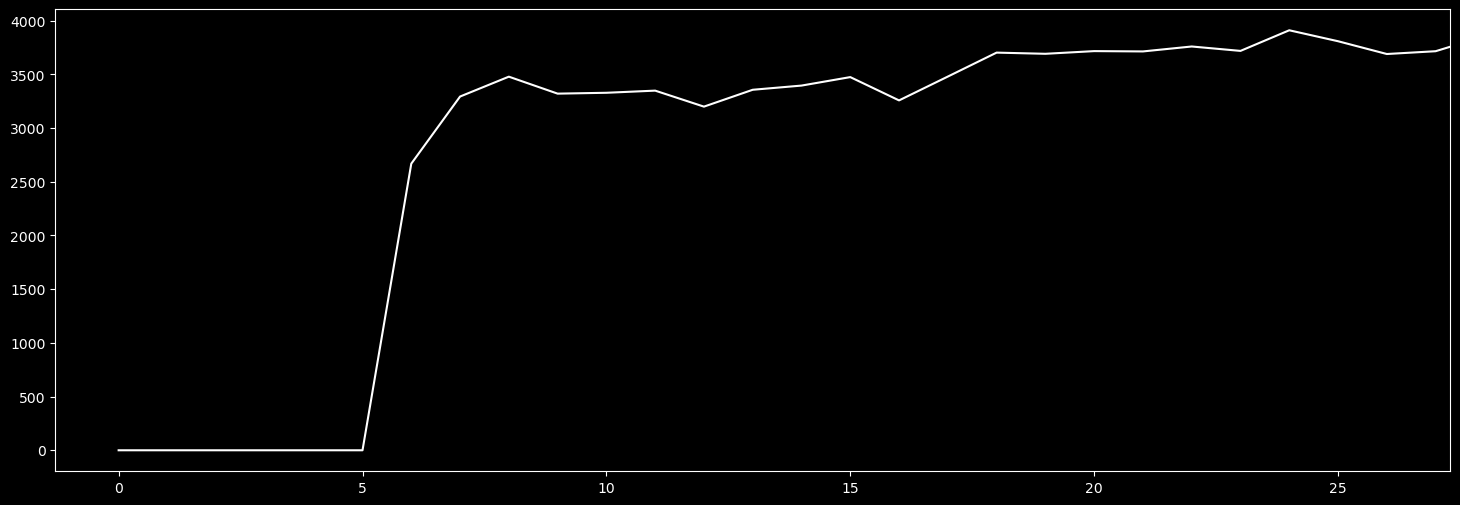

In [167]:
fig, ax = plt.subplots(1, 1, figsize = (18, 6))
line = ax.plot([], 'w-')[0]
outputs = ""
with serial.Serial("COM31", 115200) as ser:
    start_timer = time.time()
    ser.write(cmd_str.encode())
    arr = []
    last_update_time,  last_update_length = 0, 0

    while (time.time() - start_timer < 2):
        if ser.in_waiting > 2:
            start_timer = time.time()
            l = ser.readline().decode().strip()
            if l[0] == '[':
                outputs += l + "\n"
            elif l[0].isdigit() and l[-1].isdigit():
                if l.count(',') == 5:
                    _arr = np.fromstring(l, sep = ',', dtype=int).tolist()
                    arr.append(_arr)
                else:
                    print(l)
            else:
                print(l)
        else:
            if (len(arr) - last_update_length > 1) and (time.time() - last_update_time > .01):
                plot_arr = np.array(arr)
                line.set_data(np.arange(plot_arr.shape[0]), plot_arr[:, 0])
                ax.autoscale_view(True, True) 
                ax.relim()
                
                last_update_length = len(arr)
                last_update_time = time.time()
                display(fig)
                clear_output(wait=True)

                plt.pause(0.0001)
            else:
                time.sleep(0.2)

                
plt.show()    

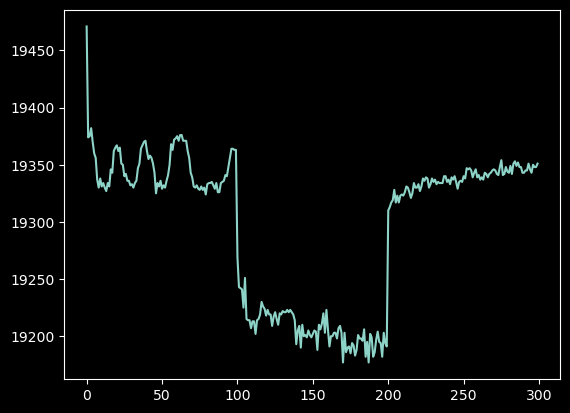

In [157]:
plt.plot(plot_arr[:, 1])
#plt.plot(plot_arr[:, 1])

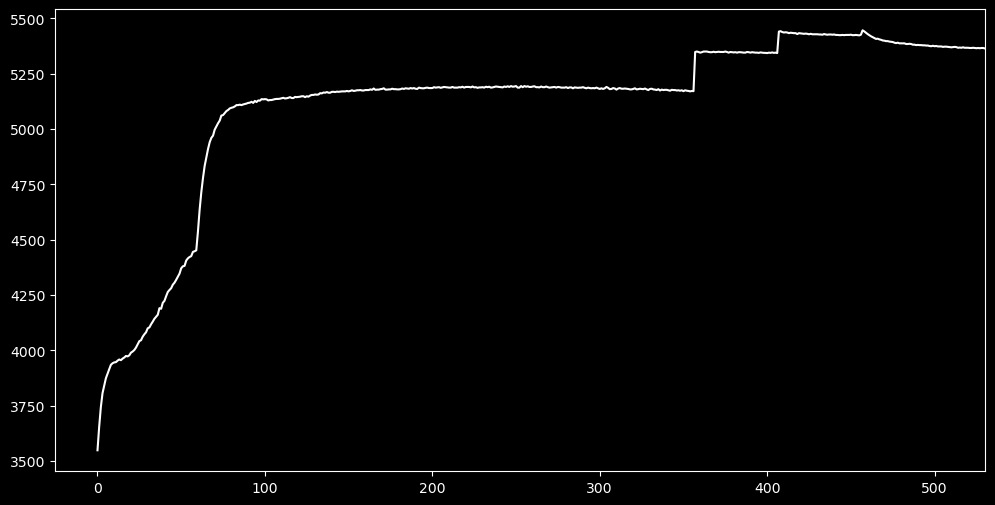

In [169]:
fig, ax = plt.subplots(1, 1, figsize = (12, 6))
line = ax.plot([], 'w-')[0]
outputs = ""
with serial.Serial("COM31", 115200) as ser:
    start_timer = time.time()
    ser.write("mpf, 1, 1".encode())
    arr = []
    last_update_time,  last_update_length = 0, 0

    while (time.time() - start_timer < 2):
        if ser.in_waiting > 2:
            start_timer = time.time()
            l = ser.readline().decode().strip()
            if l[0] == '[':
                outputs += l + "\n"
            elif (l[0].isdigit() and l[-1].isdigit()) or (l[1].isdigit() and l[-1].isdigit()):
                if l.count(',') == 1:
                    _arr = np.fromstring(l, sep = ',', dtype=int).tolist()
                    arr.append(_arr)
                else:
                    print(l)
            else:
                print(l)
        else:
            if (len(arr) - last_update_length > 1) and (time.time() - last_update_time > .01):
                plot_arr = np.array(arr)
                line.set_data(np.arange(plot_arr.shape[0]), plot_arr[:, 0])
                ax.autoscale_view(True, True) 
                ax.relim()
                
                last_update_length = len(arr)
                last_update_time = time.time()
                display(fig)
                clear_output(wait=True)

                plt.pause(0.0001)
            else:
                time.sleep(0.2)

                
plt.show()    

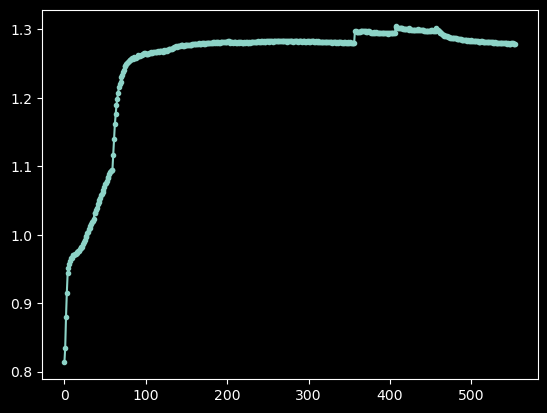

In [170]:
plt.plot(plot_arr[:,0] / plot_arr[:,1], '.-')

In [171]:
tl = []
for x in range(5):
    tl += (np.arange(12) * 120 + x * 1500).tolist()
_z = tl[-1]
for x in range(495):
    tl += [x * 1500 + _z]

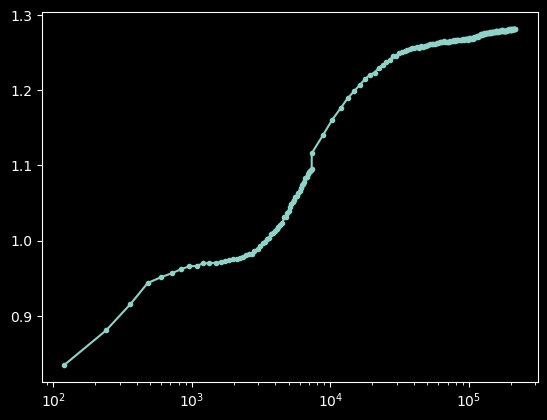

In [172]:
plt.plot(tl[1:200], plot_arr[1:200,0] / plot_arr[1:200,1], '.-')
plt.xscale('log')

In [61]:
print(outputs)

[  4942][V][u_adpd6100.cpp:584] preset_config_1(): [ADPD] Preset_config 1 set for timeslot:0. Two ambient channels. Total 6 bytes
[  4943][V][u_adpd6100.cpp:631] preset_config_2(): [ADPD] Preset_config 2 set for timeslot:1. Total 8 bytes
[  4953][I][PAM.cpp:37] detector_preset_1(): [PAM] Preset 1 set
[  4958][V][do_c.cpp:83] detector_preset(): [DO_C] ADPD detector preset with current: 50
[  4965][V][do_c.cpp:43] arr_set(): [DO_C] Set line 0 to type 1 with 100 x 10Hz samples, actinic:0, sub:1
[  4975][V][PAM.cpp:74] run_preprocess(): [PAM] Run type:1, number:100, freq: 10, actinic: 0, subfactor 1
[  4984][V][PAM.cpp:112] run_arr(): [PAM] Sample: 100, ref: 100, amb: 100, dark: 100
[  4991][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created
[  4998][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created
[  5004][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created
[  5011][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created
[  5017][V][data

In [48]:

def line_parse(l:str)->str:
    l = l.strip()
    if len(l) < 1:return ""
    if l[0] == '[':
        print(l)
        return ""
    else:
        return l.strip()

with serial.Serial("COM4", 115200, timeout = 5) as ser:


    ser.write(cmd_str.encode())
    data_ready = False
    checked = False
    ts = time.time()
    while time.time() - ts < 1:
        if ser.in_waiting > 0:
            l = line_parse(ser.readline().decode())
            if l == "Wake!":
                ser.write("Ready".encode())
                data_ready = True
            elif data_ready and l.isdigit():
                ts = time.time()
                data_len = int(l)
                ser.write("GO".encode())
                a1 = ser.read(4 * (data_len + 1))
                _a = np.frombuffer(a1, dtype=">i4")
                if (_a[:-1].sum() == _a[-1]):
                    checked = True
            elif l == "DONE":
                ser.write("Check".encode())
                data_ready = False
                print(_a)

            elif l == "Finish":
                print(l)
                break
            else:
                print(l)

                

6
[ 35920][V][u_adpd6100.cpp:584] preset_config_1(): [ADPD] Preset_config 1 set for timeslot:0. Two ambient channels. Total 6 bytes

[ 35921][V][u_adpd6100.cpp:631] preset_config_2(): [ADPD] Preset_config 2 set for timeslot:1. Total 8 bytes

[ 35931][I][PAM.cpp:37] detector_preset_1(): [PAM] Preset 1 set

[ 35936][V][do_c.cpp:83] detector_preset(): [DO_C] ADPD detector preset with current: 110

[ 35943][V][do_c.cpp:43] arr_set(): [DO_C] Set line 0 to type 1 with 50 x 50Hz samples, actinic:50, sub:1

[ 35953][V][PAM.cpp:74] run_preprocess(): [PAM] Run type:1, number:50, freq: 50, actinic: 50, subfactor 1

[ 35962][V][PAM.cpp:112] run_arr(): [PAM] Sample: 50, ref: 50, amb: 50, dark: 50

[ 35969][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created

[ 35976][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created

[ 35982][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created

[ 35989][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created

[ 3599

In [41]:
_a[:-1].sum()

6932649

In [40]:
_a

array([56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363, 56363,
       56363, 56363, 56363, 56363, 56363, 56363,  7503])

In [20]:
l

'200'